In [54]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [55]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('VIDEO_DATA') 

# Actions that we try to detect
actions = np.array(['bagayak','kalamanakaru','aapasu','a','welawa','bonawa','u'])

# Thirty videos worth of data
no_sequences = 10

# Videos are going to be 30 frames in length
sequence_length = 30

In [56]:
label_map = {label:num for num, label in enumerate(actions)}

In [57]:
label_map

{'bagayak': 0,
 'kalamanakaru': 1,
 'aapasu': 2,
 'a': 3,
 'welawa': 4,
 'bonawa': 5,
 'u': 6}

In [58]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [59]:
X = np.array(sequences)

In [60]:
y = to_categorical(labels).astype(int)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [62]:
print(X_train.shape)
print(X_test.shape)

(56, 30, 258)
(14, 30, 258)


In [63]:
# Build and Train LSTM Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [64]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [65]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 258)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [66]:
res = [.7, 0.2, 0.1]

In [67]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [68]:
#history = model.fit(X_train, y_train, epochs=800, callbacks=[tb_callback])

In [70]:
history = model.fit(X_train, y_train, epochs=800, callbacks=[tb_callback], validation_data=(X_test, y_test))


Epoch 1/800
2/2 [==============================] - 1s 140ms/step - loss: 1.4615e-05 - categorical_accuracy: 1.0000 - val_loss: 1.8705 - val_categorical_accuracy: 0.8571
Epoch 2/800
2/2 [==============================] - 0s 99ms/step - loss: 1.4562e-05 - categorical_accuracy: 1.0000 - val_loss: 1.8715 - val_categorical_accuracy: 0.8571
Epoch 3/800
2/2 [==============================] - 0s 93ms/step - loss: 1.4519e-05 - categorical_accuracy: 1.0000 - val_loss: 1.8731 - val_categorical_accuracy: 0.8571
Epoch 4/800
2/2 [==============================] - 0s 92ms/step - loss: 1.4462e-05 - categorical_accuracy: 1.0000 - val_loss: 1.8745 - val_categorical_accuracy: 0.8571
Epoch 5/800
2/2 [==============================] - 0s 89ms/step - loss: 1.4423e-05 - categorical_accuracy: 1.0000 - val_loss: 1.8762 - val_categorical_accuracy: 0.8571
Epoch 6/800
2/2 [==============================] - 0s 91ms/step - loss: 1.4379e-05 - categorical_accuracy: 1.0000 - val_loss: 1.8792 - val_categorical_accuracy

In [71]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test loss and test accuracy
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 [==============================] - 0s 40ms/step - loss: 2.3746 - categorical_accuracy: 0.8571
Test Loss: 2.3746
Test Accuracy: 0.8571


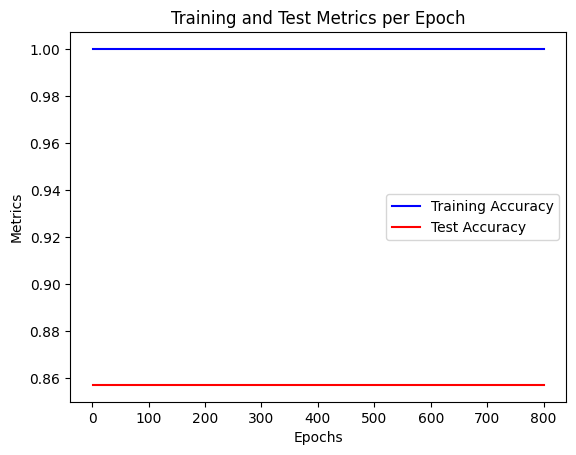

In [72]:
training_accuracy = history.history['categorical_accuracy']
test_accuracy = history.history['val_categorical_accuracy']
test_loss = history.history['val_loss']

epochs = range(1, len(training_accuracy) + 1)

plt.plot(epochs, training_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, test_accuracy, 'r', label='Test Accuracy')
# plt.plot(epochs, test_loss, 'g', label='Test Loss')
plt.title('Training and Test Metrics per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.legend()
plt.show()

In [73]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 64)            82688     
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 7)                 231       
                                                                 
Total params: 237,383
Trainable params: 237,383
Non-tr

In [74]:
# Make Predictions
res = model.predict(X_test)

1/1 [==============================] - 1s 788ms/step


In [75]:
actions[np.argmax(res[0])]

'welawa'

In [76]:
actions[np.argmax(y_test[0])]

'welawa'

In [77]:
# Save Weights
model.save('action.h5')

In [78]:
# Evaluation using Confusion Matrix and Accuracy
yhat = model.predict(X_test)

1/1 [==============================] - 0s 34ms/step


In [79]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [80]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [81]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[10,  0],
        [ 0,  4]],

       [[11,  0],
        [ 2,  1]],

       [[13,  0],
        [ 0,  1]],

       [[10,  2],
        [ 0,  2]],

       [[11,  0],
        [ 0,  3]],

       [[13,  0],
        [ 0,  1]]], dtype=int64)

In [82]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 [==============================] - 0s 39ms/step - loss: 2.3746 - categorical_accuracy: 0.8571
Test Loss: 2.3746092319488525
Test Accuracy: 0.8571428656578064


In [83]:
accuracy_score(ytrue, yhat)

0.8571428571428571